In [ ]:
import sys
from pathlib import Path

# Ensure repo root is on sys.path so `from tools...` imports work from any notebook subfolder.
_p = Path.cwd().resolve()
for _parent in [_p, *_p.parents]:
    if (_parent / 'tools' / 'search_tools.py').exists():
        sys.path.insert(0, str(_parent))
        break
del _p, _parent


In [5]:
%%capture --no-stderr
# %pip install "autogen-agentchat~=0.2.3"

# In Your OAI_CONFIG_LIST file, you must have two configs,
# one with:           "response_format": { "type": "text" }
# and the other with: "response_format": { "type": "json_object" }


[
    {"model": "gpt-4o-mini", "sk-REDACTED": "key go here", "response_format": {"type": "text"}},
]

In [6]:
import autogen
import os
from autogen.agentchat import UserProxyAgent
from autogen.agentchat.assistant_agent import AssistantAgent
from autogen.agentchat.groupchat import GroupChat
os.environ["SERPER_API_KEY"] = "1edefaec0732d11db50b993ba60539510cc55334"
from tools.search_tools import SearchTools




In [7]:
from autogen import ConversableAgent
from autogen import register_function

import os
import json
import requests

def search_internet(query: str) -> str:
        """Useful to search the internet
        about a a given topic and return relevant results"""
        print("Searching the internet...")
        top_result_to_return = 5
        url = "https://google.serper.dev/search"
        payload = json.dumps(
            {"q": query, "num": top_result_to_return, "tbm": "nws"})
        headers = {
            'X-API-KEY': os.environ['SERPER_API_KEY'],
            'content-type': 'application/json'
        }
        response = requests.request("POST", url, headers=headers, data=payload)
        # check if there is an organic key
        if 'organic' not in response.json():
            return "Sorry, I couldn't find anything about that, there could be an error with you serper api key."
        else:
            results = response.json()['organic']
            string = []
            print("Results:", results[:top_result_to_return])
            for result in results[:top_result_to_return]:
                try:
                    # Attempt to extract the date
                    date = result.get('date', 'Date not available')
                    string.append('\n'.join([
                        f"Title: {result['title']}",
                        f"Link: {result['link']}",
                        f"Date: {date}",  # Include the date in the output
                        f"Snippet: {result['snippet']}",
                        "\n-----------------"
                    ]))
                except KeyError:
                    next

            return '\n'.join(string)

        



In [8]:
import asyncio
import autogen
import os
import httpx
from typing import Optional, List, Dict, Tuple, Union
import random  # noqa E402

import matplotlib.pyplot as plt  # noqa E402
import networkx as nx  # noqa E402

import autogen  # noqa E402
from autogen.agentchat.conversable_agent import ConversableAgent  # noqa E402
from autogen.agentchat.assistant_agent import AssistantAgent  # noqa E402
from autogen.agentchat.groupchat import GroupChat  # noqa E402
from autogen.graph_utils import visualize_speaker_transitions_dict 

# Set your OpenAI API key
os.environ["OPENAI_API_KEY"] = "sk-REDACTED"

# Define a custom HTTP client
class MyHttpClient(httpx.Client):
    def __deepcopy__(self, memo):
        return self
    
llm_config = {
    "config_list": [
        {
            "model": "qwen2.5:72b",
            "api_type": "ollama",
            "client_host": "https://7r9o21n06von58-11434.proxy.runpod.net/",
        }
    ]
}




def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


user_proxy = autogen.UserProxyAgent(
    name="User_proxy",
    system_message="A human admin who terminates the chat when the leader agent sends a message with 'TERMINATE' mentioned it it",
    code_execution_config=False,
    human_input_mode="NEVER",
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    llm_config=llm_config,
)

Leader = ConversableAgent(
    name="Leader",
    system_message=(
        "You are the Leader.\n"
        "You oversee 4 agents (A,B,C,D) who must schedule multiple resources (A,B,C) with constraints and maintenance.\n"
        "You do not solve directly, but gather their proposals, resolve conflicts, reassign tasks, and finalize a feasible schedule.\n"
        "When done, say 'TERMINATE'.\n"

    ),
    llm_config=llm_config,
)



AgentA = ConversableAgent(
    name="Agent_A",
    system_message=(
        "You are Agent A.\n"
        "You must schedule Resource A->B in sequence, M-W 8-4, finish in 3 days.\n"
        "You must cooperate with B,C,D to avoid conflicts.\n"
        "Follow Leader’s instructions.\n"

    ),
    llm_config=llm_config,
)



AgentB = ConversableAgent(
    name="Agent_B",
    system_message=(
        "You are Agent B.\n"
        "You need B and C simultaneously, prefer 10pm-6am, finish in 2 days.\n"
        "Depends on A's output.\n"
        "Cooperate with others, follow Leader.\n"

    ),
    llm_config=llm_config,
)


 
AgentC = ConversableAgent(
    name="Agent_C",
    system_message=(
        "You are Agent C.\n"
        "You need Resource A for 12h, flexible but avoid A's maintenance.\n"
        "Cooperate, follow Leader.\n"

    ),
    llm_config=llm_config,
)


AgentD = ConversableAgent(
    name="Agent_D",
    system_message=(
        "You are Agent D.\n"
        "You need C for urgent 2h tasks arriving anytime.\n"
        "High priority, can preempt.\n"
        "Cooperate, follow Leader.\n"

    ),
    llm_config=llm_config,
)



Agent5 = ConversableAgent(
    name="Tool_executor",
    system_message=( 
        "You are responsible for executing the tools"
    ),
    # llm_config={"config_list": [{"model": "gpt-4o-mini", "api_key": os.environ.get("OPENAI_API_KEY")}]}
    llm_config=llm_config,
)




In [9]:
# import requests
# import json

# def query_ollama(prompt, model="qwen2.5:72b"):
#     url = "https://3s8bwscehzgw0q-11434.proxy.runpod.net/api/generate"  # Ensure correct endpoint
#     payload = {"model": model, "prompt": prompt}
    
#     try:
#         response = requests.post(url, json=payload)
#         response.raise_for_status()  # Check for HTTP errors
        
#         # Process response line by line
#         result = ""
#         for line in response.text.splitlines():
#             try:
#                 line_data = json.loads(line)
#                 result += line_data.get("response", "")
#                 if line_data.get("done", False):
#                     break
#             except json.JSONDecodeError:
#                 continue  # Ignore lines that aren't valid JSON
                
#         return result.strip()  # Return the concatenated response
#     except requests.exceptions.RequestException as e:
#         return {"error": "Request failed", "details": str(e)}

In [10]:
# # Add a global or class-level variable to track the first call
# is_first_call = True  # This flag tracks if the function is being called for the first time

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Agent3" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#     "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Summarizer_Agent_1, Summarizer_Agent_2, Summarizer_Agent_3 and Leader. "
#     "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#     f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_ollama(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response  # Replace 'text' with the correct key

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


In [11]:
# # Add global variables to track the first call and the call count
# is_first_call = True  # Tracks if this is the first call
# call_count = 0        # Tracks the number of times the function has been called

# def custom_speaker_selection_func(last_speaker, groupchat):
#     global is_first_call, call_count

#     # If this is the first call, return the leader agent
#     if is_first_call:
#         is_first_call = False  # Reset the flag after the first call
#         print("First call detected. Setting speaker to Leader agent.")

#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Increment the call count
#     call_count += 1

#     # If this is the 7th call, return the leader agent
#     if call_count % 7 == 0:
#         print(f"7th call detected (call count: {call_count}). Setting speaker to Leader agent.")
#         for agent in groupchat.agents:
#             if agent.name == "Leader":  # Replace "Leader" with the actual leader agent's name
#                 return agent
#         print("Error: Leader agent not found in the agents list.")
#         return None  # Handle the case where the leader agent is not found

#     # Access the last message in the group chat
#     last_message = groupchat.messages[-1]
#     print(f"Last message content: {last_message}")

#     # Prepare the input for the LLM
#     prompt = (
#         "You are a conversation coordinator. Based on the last message, decide which agent should speak next out of the following Production_Manager, Logistics_Manager, A/P—A/R_Manager, Customer_Relations/Marketing_Manager and Leader. "
#         "ONLY RESPOND WITH THE NAME OF THE AGENT AND NOTHING ELSE. NO OTHER CHARACTERS SHOULD BE THERE IN YOUR MESSAGE.\n\n"
#         f"The last message is: {last_message.get('content', '')}"
#     )

#     # Analyze the message using the local LLM
#     response = query_ollama(prompt)
#     print(f"LLM response: {response}")

#     # Extract the relevant text from the response dictionary
#     next_speaker_name = response.strip()  # Use .strip() to remove any extra spaces or newlines

#     # Find the corresponding agent in the group chat
#     for agent in groupchat.agents:
#         if agent.name == next_speaker_name:
#             return agent

#     # If no valid agent is found, return None or a default fallback
#     print(f"No valid agent found for the name: {next_speaker_name}")
#     return None


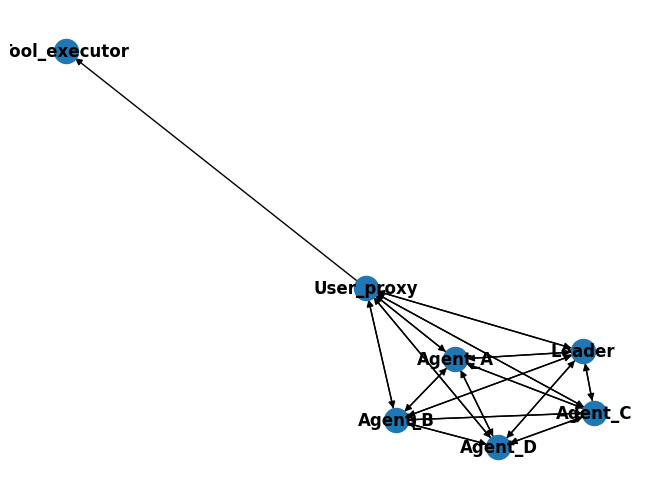

In [12]:
# Define your agents
agents = [AgentA, AgentB, AgentC, AgentD, Leader, user_proxy, Agent5]

# Initialize the allowed speaker transitions dictionary
allowed_speaker_transitions_dict = {}

# Set up transitions for each agent
for agent in agents:
    if agent == Agent5:
        # Agent5 cannot send messages to any agent
        allowed_speaker_transitions_dict[agent] = []
    else:
        # Other agents can send messages to all agents except themselves and Agent5
        allowed_speaker_transitions_dict[agent] = [
            other_agent for other_agent in agents
            if other_agent != agent and other_agent != Agent5
        ]

# Allow user_proxy to send messages to Agent5
allowed_speaker_transitions_dict[user_proxy].append(Agent5)

# Visualize the transitions
visualize_speaker_transitions_dict(allowed_speaker_transitions_dict, agents)


In [13]:
def is_termination_msg(content) -> bool:
    have_content = content.get("content", None) is not None
    if have_content and "TERMINATE" in content["content"]:
        return True
    return False


agents.append(user_proxy)

group_chat = GroupChat(
    agents=agents,
    messages=[],
    max_round=100,
    allowed_or_disallowed_speaker_transitions=allowed_speaker_transitions_dict,
    speaker_transitions_type="allowed",
)
# Create the manager
manager = autogen.GroupChatManager(
    groupchat=group_chat,
    llm_config=llm_config,
    is_termination_msg=lambda x: x.get("content", "").find("TERMINATE") >= 0,
    code_execution_config=False,
)


In [14]:
# from autogen import register_function


# register_function(
#     search_internet,
#     caller=Leader,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="search",  # By default, the function name is used as the tool name.
#     description="browse the internet for information using this tool",  # A description of the tool
# )

# register_function(
#     search_internet,
#     caller=Agent1,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="search",  # By default, the function name is used as the tool name.
#     description="browse the internet for information using this tool",  # A description of the tool
# )

# register_function(
#     search_internet,
#     caller=Agent2,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="search",  # By default, the function name is used as the tool name.
#     description="browse the internet for information using this tool",  # A description of the tool
# )

# register_function(
#     search_internet,
#     caller=Agent3,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="search",  # By default, the function name is used as the tool name.
#     description="browse the internet for information using this tool",  # A description of the tool
# )

# register_function(
#     search_internet,
#     caller=Agent4,  # The assistant agent can suggest calls to the calculator.
#     executor=Agent5,  # The user proxy agent can execute the calculator calls.
#     name="search",  # By default, the function name is used as the tool name.
#     description="browse the internet for information using this tool",  # A description of the tool
# )

In [15]:
# chat_result = user_proxy.initiate_chat(Agent0, message="search internet about google. Use production Manager first")

In [ ]:
# Prepare the initial message with the novel's text
initial_message = ("Start with assigning tasks. Agents A,B,C,D: Present your constraints. Start scheduling.\n")

# Initiate the conversation
user_proxy.initiate_chat(manager, message=initial_message)

User_proxy (to chat_manager):

Start with assigning tasks. Agents A,B,C,D: Present your constraints. Start scheduling.


--------------------------------------------------------------------------------

Next speaker: Agent_A


>>>>>>>> USING AUTO REPLY...
Agent_A (to chat_manager):

**Agent A:** I need to schedule Resource A->B in sequence from Monday to Wednesday, 8 AM to 4 PM, and complete the task within 3 days. I will coordinate with Agents B, C, and D to avoid any conflicts.

**Agents, please present your constraints:**

- **Agent B:** What are your current tasks or availability during this period?
- **Agent C:** Do you have any scheduled activities that might overlap with the proposed time frame?
- **Agent D:** Are there any constraints or existing commitments that I should be aware of?

Once I have this information, I can start scheduling the tasks.

--------------------------------------------------------------------------------

Next speaker: Agent_B


>>>>>>>> USING AUTO REPL

ChatResult(chat_id=None, chat_history=[{'content': 'Start with assigning tasks. Agents A,B,C,D: Present your constraints. Start scheduling.\n', 'role': 'assistant', 'name': 'User_proxy'}, {'content': '**Agent A:** I need to schedule Resource A->B in sequence from Monday to Wednesday, 8 AM to 4 PM, and complete the task within 3 days. I will coordinate with Agents B, C, and D to avoid any conflicts.\n\n**Agents, please present your constraints:**\n\n- **Agent B:** What are your current tasks or availability during this period?\n- **Agent C:** Do you have any scheduled activities that might overlap with the proposed time frame?\n- **Agent D:** Are there any constraints or existing commitments that I should be aware of?\n\nOnce I have this information, I can start scheduling the tasks.', 'name': 'Agent_A', 'role': 'user'}, {'content': '**Agent A:** I need to schedule Resource A->B in sequence from Monday to Wednesday, 8 AM to 4 PM, and complete the task within 3 days. I will coordinate wi

In [17]:
last_message = group_chat.messages[-1] if group_chat.messages else None
if last_message:
    print("Final Message Content:", last_message['content'])

Final Message Content: Thank you for your detailed confirmations and readiness to proceed with the finalized schedule. It's great to see that everyone is aligned and prepared.

### **Finalized Schedule:**

#### **Monday:**
- **8 AM to 4 PM:** Agent A works on Resource A->B (Day 1).

#### **Tuesday:**
- **8 AM to 4 PM:** Agent A continues working on Resource A->B (Day 2).
- **4 PM to 4 AM (Wednesday):** Agent C uses the 12-hour window for their task.

#### **Wednesday:**
- **4 AM to 6 AM:** Agent B starts tasks.
- **8 AM to 4 PM:** Agent A completes the final day of work on Resource A->B (Day 3).
- **6 AM to 10 PM:** Agent B continues working on tasks.

#### **Thursday:**
- **10 PM to 6 AM (Friday):** Agent B completes remaining tasks.

### **Additional Considerations:**
- **Agent D's Routine Maintenance:** Can be scheduled outside peak hours, such as early morning or late afternoon.
- **High-Priority Tasks (HPTs):** Agent D will notify the team with a 2-hour notice if an HPT arises. We

In [18]:
def save_conversation_to_file(groupchat, filename="chat.txt"):
    """
    Save the entire conversation history to a specified file.

    Args:
        groupchat (GroupChat): The GroupChat instance containing the messages.
        filename (str): The name of the file to save the conversation history.
    """
    if not groupchat.messages:
        print("No messages in the group chat to save.")
        return

    # Compile the conversation history
    conversation_history = "\n".join(
        f"{msg['role']}: {msg['content']}" for msg in groupchat.messages
    )

    # Write the conversation history to the file
    with open(filename, "w", encoding="utf-8") as file:
        file.write(conversation_history)

    print(f"Conversation history saved to {filename}")
    
save_conversation_to_file(group_chat, filename="chat.txt")


Conversation history saved to chat.txt


In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

# Initialize the Llama 3.1 model
llm = ChatOpenAI(
    model="llama3.1",
    base_url="http://44.221.48.158:11434/v1"
)

def structure_logs_with_local_llm(file_path, initial_message):
    """
    Reads chat logs from a file and generates a structured summary.

    Args:
        file_path (str): Path to the chat log file.
        initial_message (str): The initial task or prompt for context.

    Returns:
        str: The structured summary generated by the LLM.
    """
    # Read the chat logs from the file
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            log_context = file.read()
    except FileNotFoundError:
        return "Error: The specified file was not found."
    except Exception as e:
        return f"An error occurred while reading the file: {e}"

    # Prepare the messages for the LLM
    messages = [
        {
            "role": "system",
            "content": (
                "You are a professional chat summarizer who goes through the entire chat and creates a proper summary based on the '{initial_message}'."
            )
        },
        {
            "role": "user",
            "content": (
                f"Convert the following agent logs into a structured format and into a proper summarized final output "
                f"based on the task '{initial_message}'.\n\nLogs:\n{log_context}"
            )
        }
    ]

    # Generate the structured summary using the LLM
    try:
        response = llm.invoke(messages)
        if isinstance(response, AIMessage):
            structured_summary = response.content
        else:
            structured_summary = "Unexpected response type from the model."
    except Exception as e:
        structured_summary = f"An error occurred during LLM processing: {e}"

    return structured_summary


In [20]:
# Define the path to your chat log file and the initial task message
file_path = 'chat.txt'
initial_message = 'Design a comprehensive digital marketing course.'

# Generate the structured summary
summary = structure_logs_with_local_llm(file_path, initial_message)

# Output the summary
print(summary)

An error occurred during LLM processing: Request timed out.


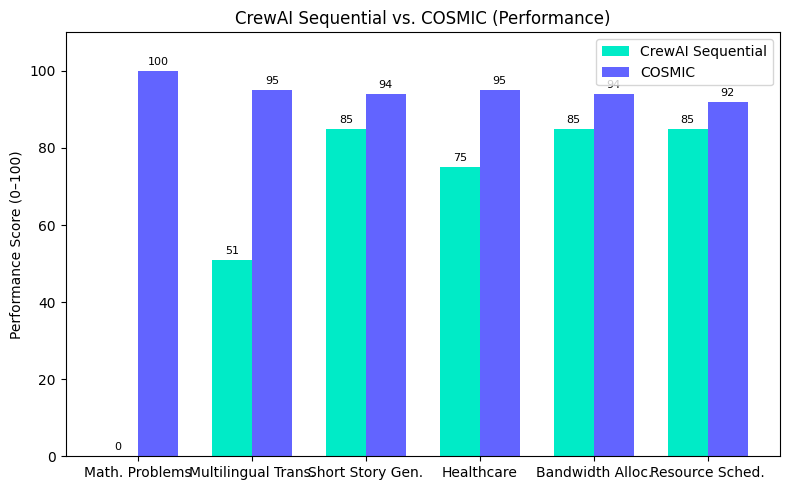

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----- Data -----
tasks = [
    "Math. Problems", 
    "Multilingual Trans.",
    "Short Story Gen.",
    "Healthcare",
    "Bandwidth Alloc.",
    "Resource Sched."
]

# Scores out of 100 (example data)
crewai_seq_scores = [0, 51, 85, 75, 85, 85]
cosmic_scores     = [100, 95, 94, 95, 94, 92]

# ----- Colors -----
crew_color = "#00EBC7"  # Teal from logo
cosmic_color = "#6264FF"  # Blue from logo

# ----- Plotting -----
x = np.arange(len(tasks))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, crewai_seq_scores, width, label='CrewAI Sequential', color=crew_color)
rects2 = ax.bar(x + width/2, cosmic_scores,     width, label='COSMIC', color=cosmic_color)

ax.set_ylabel('Performance Score (0–100)')
ax.set_title('CrewAI Sequential vs. COSMIC (Performance)')
ax.set_xticks(x)
ax.set_xticklabels(tasks, rotation=0)
ax.set_ylim(0, 110)
ax.legend()

# Annotate
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height}',
                xy=(rect.get_x() + rect.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
